In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from multicamera_airflow_pipeline.jonah_241112.skeletons.defaults import (
    dataset_info,
    kpt_dict,  # keypoint_name: id
    keypoint_info,
    conf_thresholds_by_camera,
    skeleton_info
)

from multicamera_airflow_pipeline.jonah_241112.keypoints.continuous_variables import load_memmap_from_filename

In [59]:
coords_file = Path("/n/groups/datta/kpts_pipeline/jonah_241112/results/gimbal/20241029_J08102/gimbal.float32.216008x14x3.mmap")
bodyparts = list(kpt_dict.keys())
bodyparts.remove("tail_tip")  # tail tip excluded from gimbal

# coords_file = Path("/n/groups/datta/kpts_pipeline/jonah_241112/results/triangulation/20241029_J08102/predictions_3d.float32.216008x15x3.mmap")
# bodyparts = list(kpt_dict.keys())

coords = load_memmap_from_filename(coords_file).copy()
coords[:,:,2] = -coords[:,:,2]  # flip z axis for easy viz


In [60]:
def color_2_mpl(color):
    return np.array(color)[::-1].reshape(1,-1) / 255

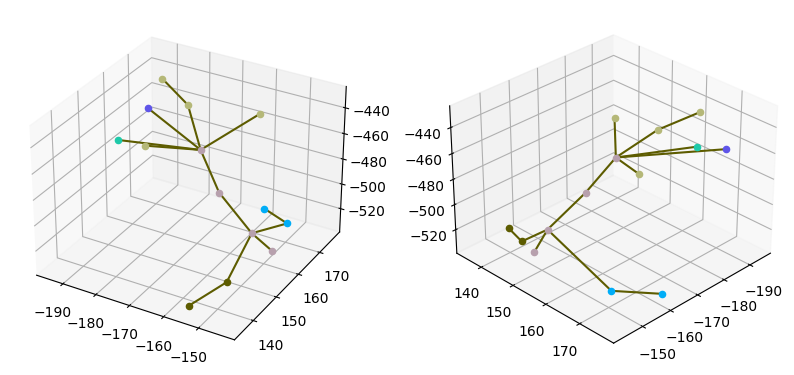

In [65]:
frame_idx = 22000

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(121, projection='3d')
for i, bp in enumerate(bodyparts):
    color = color_2_mpl(keypoint_info[kpt_dict[bp]]["color"])
    ax.scatter(*coords[frame_idx, i], label=bp, c=color)
for i, sk in skeleton_info.items():
    if "tail_tip" in sk["link"]:
        continue
    bps = sk["link"]
    color = color_2_mpl(keypoint_info[kpt_dict[bp]]["color"])
    bp_idxs = [bodyparts.index(bp) for bp in bps]
    ax.plot(*coords[frame_idx, bp_idxs].T, c=color)
    
# Show the same data but w the camera rotated 45 deg on the next plot
ax = fig.add_subplot(122, projection='3d')
for i, bp in enumerate(bodyparts):
    color = color_2_mpl(keypoint_info[kpt_dict[bp]]["color"])
    ax.scatter(*coords[frame_idx, i], label=bp, c=color)
for i, sk in skeleton_info.items():
    if "tail_tip" in sk["link"]:
        continue
    bps = sk["link"]
    color = color_2_mpl(keypoint_info[kpt_dict[bp]]["color"])
    bp_idxs = [bodyparts.index(bp) for bp in bps]
    ax.plot(*coords[frame_idx, bp_idxs].T, c=color)
ax.view_init(elev=30, azim=45)
plt.show()